<a href="https://colab.research.google.com/github/kevinmullet/E-commercePrediction/blob/main/E_Commerce_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()
#https://www.kaggle.com/datasets/shriyashjagtap/e-commerce-customer-for-behavior-analysis

{}

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


<h1> Simple Data Cleaning

In [ ]:
df = df.drop_duplicates()

df['Returns'] = df['Returns'].fillna(0)

<h1> EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                250000 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


All of the columns does not have any null property, data imputation won't be necessary

In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.403076,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.490517,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


<Axes: ylabel='Product Price'>

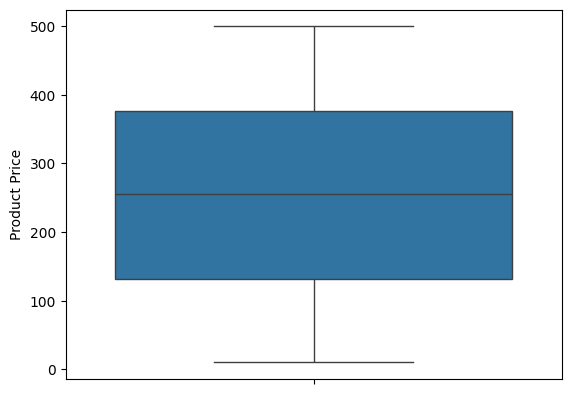

In [ ]:
sns.boxplot(df['Product Price'])

Box plot of product price and there are no outliers.

<Axes: xlabel='Churn', ylabel='count'>

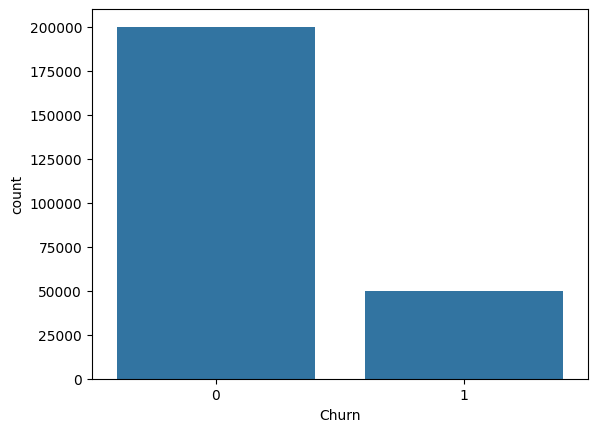

In [ ]:
sns.countplot(x="Churn", data=df)

Approximately 200,000 customers did not churn, while around 50,000 customers churned

<Axes: xlabel='Age', ylabel='Count'>

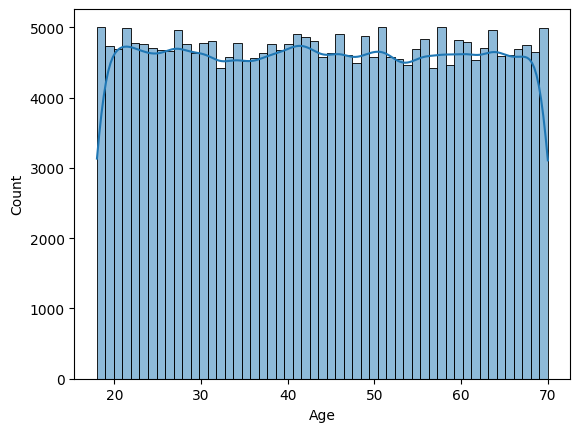

In [ ]:
sns.histplot(df['Age'],bins=53,kde=True)

The age distribution is fairly uniform across the range of 18–70 years

<Axes: xlabel='Gender', ylabel='Churn'>

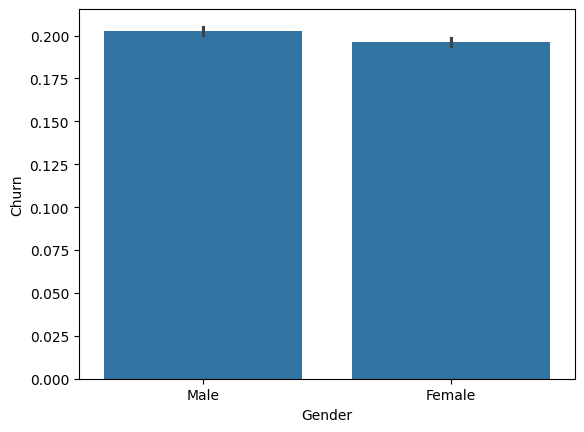

In [ ]:
sns.barplot(df,x='Gender',y='Churn')

Churn rate by gender: around 20% of male customers churned, compared to slightly under 20% of female customers. The difference is minimal, indicating that gender does not have significant impact to churn

<h1> Preprocessing

In [ ]:
cols_to_drop = ['Customer ID','Customer Name', 'Customer Age'] # dropping unnecessary columns
df = df.drop(columns=cols_to_drop)

In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date']) # converting from string/object to date format
df['Purchase Month'] = df['Purchase Date'].dt.month # extracting monthly purchase
df = df.drop(columns=['Purchase Date'])

In [ ]:
# Encoding
categorical_columns = df.select_dtypes(include='object').columns
print(categorical_columns)

df = pd.get_dummies(df,drop_first=True, columns=categorical_columns) # similar to one hot encoder (no ordinality), drop first to avoid dummy variable trap by deleting the first column of the matrix combination

Index(['Product Category', 'Payment Method', 'Gender'], dtype='object')


In [ ]:
# Seperating x and y
X = df.drop(columns='Churn')
y = df['Churn']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) # stratify for imbalanced churn/target column

<h1>Randon Forest Model

In [ ]:
# Training model
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

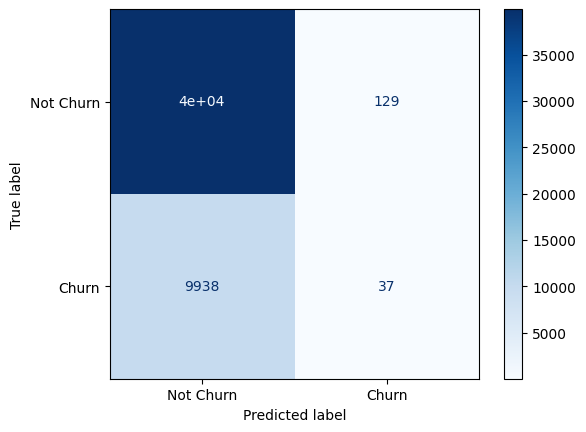

In [ ]:
# Evaluation
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.show()

The model has not learned to detect churn, resulting in very poor recall and precision for the churn class

In [ ]:
# Using feature importance to diagnose why the model fails to predict churn
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False) # (MDI) built-in importance (fast but biased towards continuous features)
print(importances.head(10))

Total Purchase Amount           0.277419
Product Price                   0.265960
Age                             0.191981
Purchase Month                  0.111784
Quantity                        0.057997
Returns                         0.018102
Payment Method_Credit Card      0.013178
Product Category_Clothing       0.012768
Payment Method_PayPal           0.011648
Product Category_Electronics    0.011372
dtype: float64


In [ ]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1') # permutation importance to measures the actual drop in F1 on unseen test data
importances_perm = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(importances_perm.head(10))

Payment Method_PayPal           0.001694
Product Category_Clothing       0.001286
Payment Method_Credit Card      0.001257
Product Price                   0.001166
Payment Method_Crypto           0.001118
Product Category_Home           0.000819
Age                             0.000809
Purchase Month                  0.000807
Quantity                        0.000803
Product Category_Electronics    0.000801
dtype: float64


MDI importance is computed on the training data and favors continuous features, because they offer many more candidate split points, so some split will fit noise by chance. Permutation importance instead shuffles one feature at a time on the test set and measures F1, so it reflects real predictive contribution and is not biased by the number of unique values.

<h1>Evaluation Result Summary



*   MDI: Total Purchase Amount, Product Price, and Age rank highest, but this method is biased toward continuous features with many possible variants of numbers.
*   Permutation Importance: All features are near zero, and several are negative, meaning none of them meaningfully help predict churn.



<h1> Next Step

Since the diagnosis (near-zero permutation importance, ~0.2% churn recall, uniform churn rates across groups) points to a lack of signal in the data rather than a weak model, switching to a more complex algorithm is unlikely to help. A simple second model such as logistic regression can be run as a sanity check, and the findings are documented as a data limitation. For a model that actually predicts churn, a dataset whose target is genuinely related to its features would be needed.

<h1> Logistic Regression Model

In [ ]:
numerical_cols = X_test.select_dtypes(include='int').columns
print(numerical_cols)

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("Scaled!")

Index(['Product Price', 'Quantity', 'Total Purchase Amount', 'Age',
       'Purchase Month'],
      dtype='object')
Scaled!


In [ ]:
X_train.head()

,Product Price,Quantity,Total Purchase Amount,Returns,Age,Purchase Month,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Payment Method_Credit Card,Payment Method_Crypto,Payment Method_PayPal,Gender_Male
69834,-0.993549,0.707750,-0.620269,1.0,-0.192864,0.539838,False,True,False,False,False,False,True
244031,-0.654584,0.001088,0.534952,0.0,1.175565,-0.950172,True,False,False,True,False,False,False
164174,-1.212463,0.001088,0.144103,0.0,0.002625,-0.652170,True,False,False,True,False,False,False
46263,0.108086,1.414413,0.988171,0.0,-1.235477,0.837840,False,False,False,True,False,False,False
236272,-0.181446,-0.705574,-1.417906,0.0,-1.039987,-0.652170,False,False,False,False,False,True,False
